<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework62.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prac 06.2

In this homework, you are going to use and compare two different trackers (of your liking) and compare the results.

### Step 1
Decide what video you are going to use for this homework, select an object and generate the template. You can use any video you want (your own, from Youtube, etc.)
and track any object you want (e.g. a car, a pedestrian, etc.).

### Step 2
Initialize a tracker (e.g. KCF).

### Step 3
Run the tracker on the video and the selected object. Run the tracker for around 10-15 frames.

### Step 4
For each frame, print the bounding box on the image and save it.

### Step 5
Select a different tracker (e.g. CSRT) and repeat steps 2, 3 and 4.

### Step 6
Compare the results:
* Do you see any differences? If so, what are they?
* Does one tracker perform better than the other? In what way?

In [43]:

!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/vid62.mp4

--2026-05-22 14:07:19--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/vid62.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12009981 (11M) [application/octet-stream]
Saving to: ‘vid62.mp4.4’

vid62.mp4.4         100%[===================>]  11.45M  --.-KB/s    in 0.03s   

2026-05-22 14:07:19 (334 MB/s) - ‘vid62.mp4.4’ saved [12009981/12009981]



In [44]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Download frames: 16


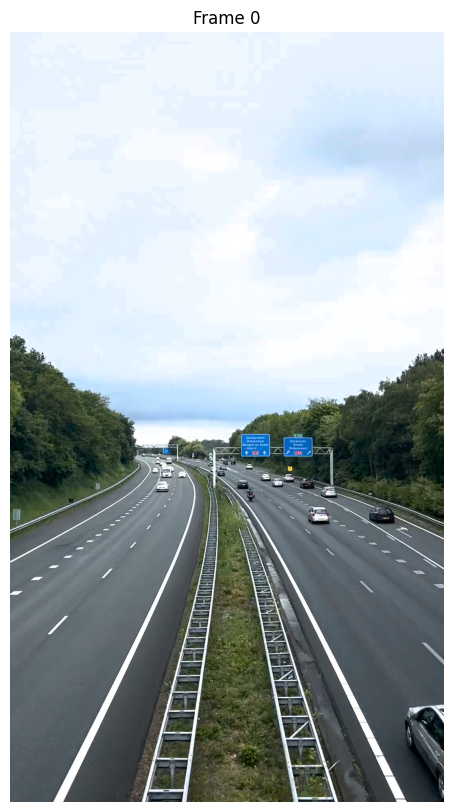

In [45]:
video = cv2.VideoCapture('/content/vid62.mp4')

frames = []
while True:
    ret, frame = video.read()
    if not ret:
        break
    frames.append(frame)
video.release()

frames = frames[::5][:16]
print(f'Download frames: {len(frames)}')

plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
plt.title('Frame 0')
plt.axis('off')
plt.show()

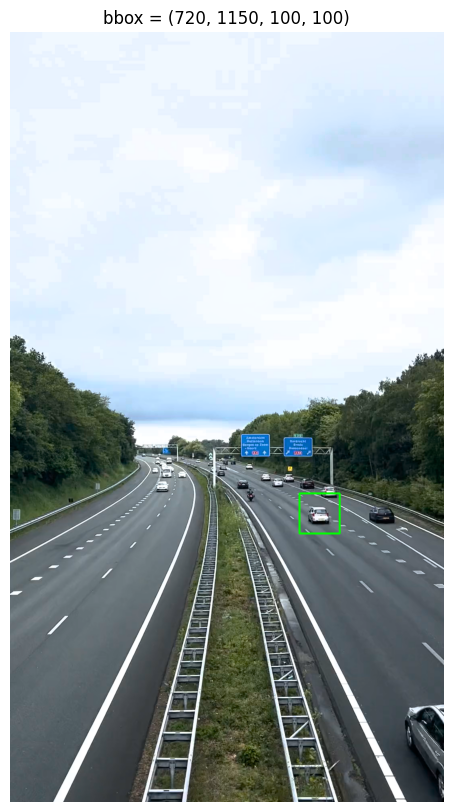

In [46]:
bbox = (720, 1150, 100, 100)

tracker_kcf = cv2.TrackerKCF_create()
tracker_kcf.init(frames[0], bbox)




test_frame = frames[0].copy()

x, y, w, h = bbox
cv2.rectangle(test_frame, (x, y), (x + w, y + h), (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(test_frame, cv2.COLOR_BGR2RGB))
plt.title(f'bbox = {bbox}')
plt.axis('off')
plt.show()

In [47]:
kcf_results = []

for i in range(1, len(frames)):
    success, box = tracker_kcf.update(frames[i])
    result = frames[i].copy()
    if success:
        x, y, w, h = [int(v) for v in box]
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(result, f'KCF {i}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    else:
        cv2.putText(result, 'KCF: Lost', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    kcf_results.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    cv2.imwrite(f'/content/kcf_frame_{i}.jpg', result)

print('KCF done')

KCF done


In [48]:
tracker_csrt = cv2.TrackerCSRT_create()
tracker_csrt.init(frames[0], bbox)

csrt_results = []

for i in range(1, len(frames)):
    success, box = tracker_csrt.update(frames[i])
    result = frames[i].copy()

    if success:
        x, y, w, h = [int(v) for v in box]
        cv2.rectangle(result, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(result, f'CSRT {i}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    else:
        cv2.putText(result, 'CSRT: Lost', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    csrt_results.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    cv2.imwrite(f'/content/csrt_frame_{i}.jpg', result)

print('CSRT done')

CSRT done


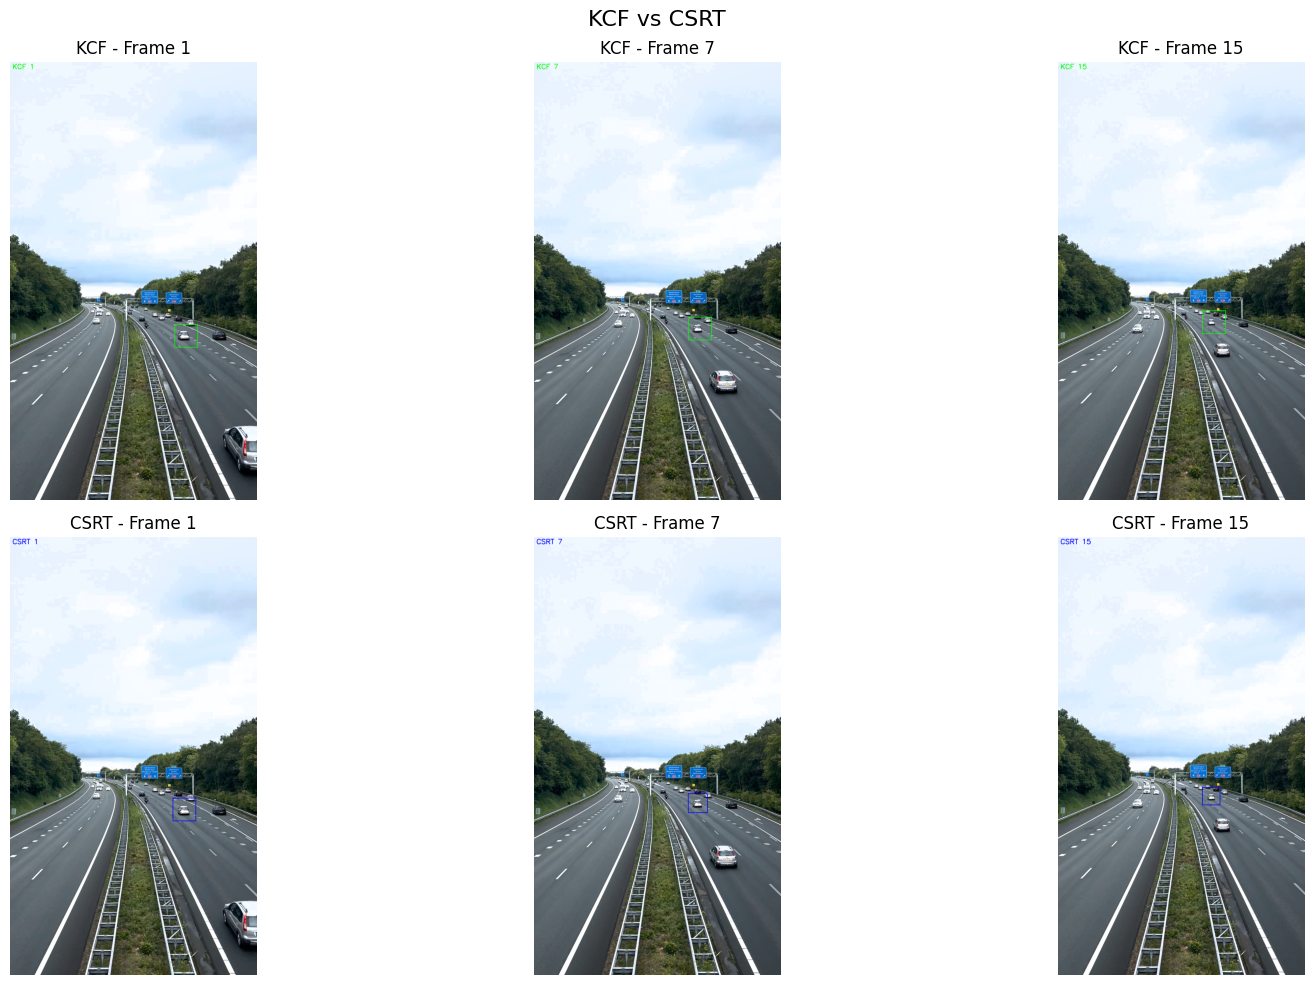

In [49]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, idx in enumerate([0, 6, 14]):
    axes[0, i].imshow(kcf_results[idx])
    axes[0, i].set_title(f'KCF - Frame {idx + 1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(csrt_results[idx])
    axes[1, i].set_title(f'CSRT - Frame {idx + 1}')
    axes[1, i].axis('off')

plt.suptitle('KCF vs CSRT', fontsize=16)
plt.tight_layout()
plt.show()


KCF is faster, but it can lose the object more easily.
CSRT is slower, but it tracks the selected car more accurately.
In this video CSRT performed better because the bounding box stayed closer to the car.
